<a href="https://colab.research.google.com/github/Edgar-Avila/007-machine-learning-no-supervisado/blob/main/07_machine_learning_no_supervisado.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris, make_moons, make_circles
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN, SpectralClustering
from sklearn.metrics import silhouette_score, adjusted_rand_score, calinski_harabasz_score

# Configuración de estilo visual
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (15, 10)

## 1. Preparación de Datasets
Generamos y escalamos los tres conjuntos de datos (Iris, Moons y Circles) para asegurar un rendimiento óptimo de los algoritmos basados en distancias.

In [2]:
# 1. Dataset Iris
iris = load_iris()
X_iris, y_iris = iris.data, iris.target
X_iris_scaled = StandardScaler().fit_transform(X_iris)

# 2. Dataset Moons (Sintético)
X_moons, y_moons = make_moons(n_samples=300, noise=0.05, random_state=42)
X_moons_scaled = StandardScaler().fit_transform(X_moons)

# 3. Dataset Circles (Sintético)
X_circles, y_circles = make_circles(n_samples=300, factor=0.5, noise=0.05, random_state=42)
X_circles_scaled = StandardScaler().fit_transform(X_circles)

datasets = {
    'Iris': (X_iris_scaled, y_iris),
    'Moons': (X_moons_scaled, y_moons),
    'Circles': (X_circles_scaled, y_circles)
}

## 2. Entrenamiento, Evaluación y Visualización

/usr/local/lib/python3.13/dist-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


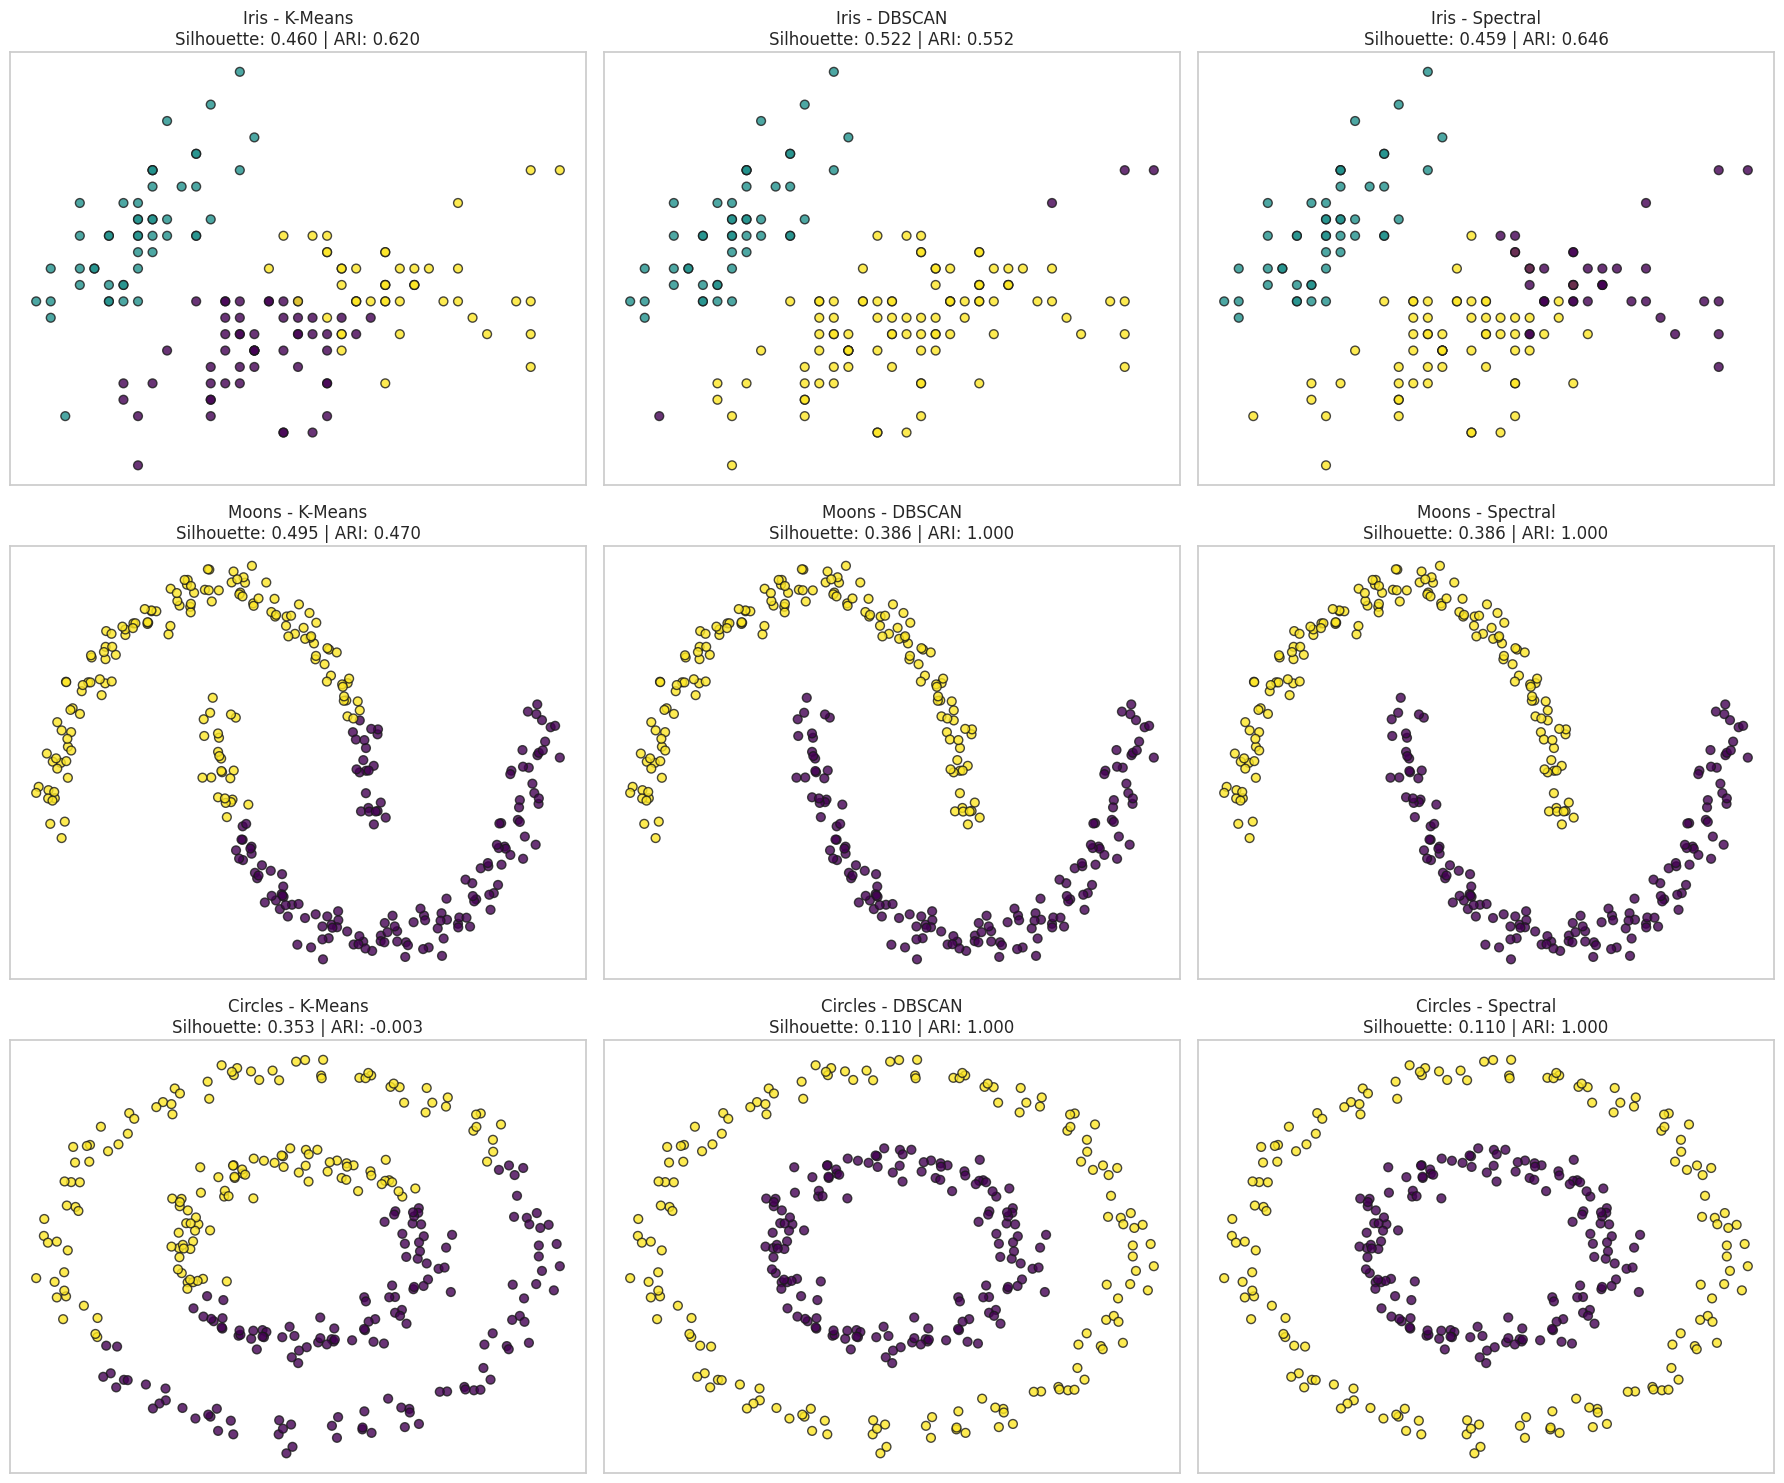

,Dataset,Model,Silhouette (Interna),ARI (Externa)
0,Iris,K-Means,0.459948,0.620135
1,Iris,DBSCAN,0.521697,0.551755
2,Iris,Spectral,0.459301,0.646487
3,Moons,K-Means,0.495363,0.469738
4,Moons,DBSCAN,0.386026,1.000000
5,Moons,Spectral,0.386026,1.000000
6,Circles,K-Means,0.353230,-0.003311
7,Circles,DBSCAN,0.109784,1.000000
8,Circles,Spectral,0.109784,1.000000


In [3]:
def evaluate_and_plot():
    fig, axes = plt.subplots(3, 3, figsize=(18, 15))
    results = []

    for row_idx, (name, (X, y_true)) in enumerate(datasets.items()):
        n_clusters = len(np.unique(y_true))

        # Configuración adaptada de modelos para cada estructura de datos
        if name == 'Iris':
            models = {
                'K-Means': KMeans(n_clusters=n_clusters, random_state=42, n_init=10),
                'DBSCAN': DBSCAN(eps=0.8, min_samples=5),
                'Spectral': SpectralClustering(n_clusters=n_clusters, affinity='nearest_neighbors', random_state=42)
            }
        elif name == 'Moons':
            models = {
                'K-Means': KMeans(n_clusters=n_clusters, random_state=42, n_init=10),
                'DBSCAN': DBSCAN(eps=0.3, min_samples=5),
                'Spectral': SpectralClustering(n_clusters=n_clusters, affinity='nearest_neighbors', random_state=42)
            }
        else: # Circles
            models = {
                'K-Means': KMeans(n_clusters=n_clusters, random_state=42, n_init=10),
                'DBSCAN': DBSCAN(eps=0.4, min_samples=5),
                'Spectral': SpectralClustering(n_clusters=n_clusters, affinity='nearest_neighbors', random_state=42)
            }

        for col_idx, (model_name, model) in enumerate(models.items()):
            # Ajuste y predicción
            y_pred = model.fit_predict(X)

            # Manejo de ruido en DBSCAN (asigna clase temporal para métricas si es necesario)
            n_labels = len(set(y_pred)) - (1 if -1 in y_pred else 0)

            # Métricas
            ari = adjusted_rand_score(y_true, y_pred)

            if n_labels > 1:
                silhouette = silhouette_score(X, y_pred)
            else:
                silhouette = np.nan # No se puede calcular con 1 solo cluster

            results.append({
                'Dataset': name,
                'Model': model_name,
                'Silhouette (Interna)': silhouette,
                'ARI (Externa)': ari
            })

            # Graficar resultados (proyección en 2D)
            ax = axes[row_idx, col_idx]
            # Usamos las primeras dos dimensiones para graficar
            scatter = ax.scatter(X[:, 0], X[:, 1], c=y_pred, cmap='viridis', s=40, edgecolors='k', alpha=0.8)
            ax.set_title(f"{name} - {model_name}\nSilhouette: {silhouette:.3f} | ARI: {ari:.3f}")
            ax.set_xticks([])
            ax.set_yticks([])

    plt.tight_layout()
    plt.show()

    return pd.DataFrame(results)

df_results = evaluate_and_plot()
display(df_results)